# hparams

| hparms | value |
|---:|---|
| batch_size | 32 |
| max_prediction_length | 24 |
| max_encoder_length | 24*7 |
| epoch | 100 |
| hidden_size | 16 |
| atten_head | 4 |

# model ckpt

| model | cpkt |
|---:|---|
| nei_0 ||
| nei_1 ||
| nei_2 ||

In [1]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

import tensorflow as tf 
import tensorboard as tb 
tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']


/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(


In [14]:
# functions
def data_processing(path):
    data = pd.read_csv(path)
    data = data[['REG_DTIME', 'h_dong', 'count', 'pops', 'windspd','humid', 'temp', 'precip_form', 'precip', 'isHoliday']]
    #data.drop('Unnamed: 0.2'   , axis=1 , inplace=True)
    #data.drop('Unnamed: 0.1'   , axis=1 , inplace=True)
    #data.drop('Unnamed: 0'   , axis=1 , inplace=True)
    data['REG_DTIME'] = pd.to_datetime(data['REG_DTIME'])
    data['DOW'] = data['REG_DTIME'].dt.dayofweek
    data['HOD'] = data['REG_DTIME'].dt.hour
    data["time_idx"] =  \
    (data["REG_DTIME"].dt.month) * data["REG_DTIME"].dt.daysinmonth * 24  + \
    data["REG_DTIME"].dt.day * 24  + \
    data["REG_DTIME"].dt.hour 
    data["time_idx"] -= data["time_idx"].min()
    #data['h_dong'] = data['h_dong'].astype(str)
    data['DOW'] = data['DOW'].astype(str)
    data['HOD'] = data['HOD'].astype(str)
    data['precip_form'] = data['precip_form'].astype(str)
    data['isHoliday'] = data['isHoliday'].astype(str)
    return data

def get_training(data , max_prediction_length, max_encoder_length):
    # traing data 생성
    max_prediction_length = max_prediction_length
    max_encoder_length = max_encoder_length
    training_cutoff = data["time_idx"].max() - max_prediction_length

    training = TimeSeriesDataSet(
        data[lambda x : x.time_idx <= training_cutoff],
        time_idx = "time_idx",
        target = "count",
        group_ids = ['h_dong'],
        min_encoder_length=max_encoder_length // 2,  # keep encoder length long (as it is in the validation set)
        max_encoder_length=max_encoder_length,
        min_prediction_length=1,
        max_prediction_length=24,
        static_categoricals=["h_dong"],
        time_varying_known_categoricals=["HOD", "DOW" , 'isHoliday'],
        time_varying_known_reals=['pops'],
        #variable_groups={"special_days": special_days},  # group of categorical variables can be treated as one variable
        time_varying_unknown_categoricals=['precip_form'],
        time_varying_unknown_reals=['count','windspd' , 'temp' ,'precip'],
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        #allow_missing=True,
        allow_missing_timesteps = True)
    return training

def get_dataloader(training, data):
    batch_size= 32
    dataloader = training.to_dataloader(batch_size)
    validation = TimeSeriesDataSet.from_dataset(training, data, predict=True, stop_randomization=True)
    train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
    val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size*100, num_workers=0)
    return train_dataloader, val_dataloader

def get_training_day(data , max_prediction_length, max_encoder_length , n):
    # traing data 생성
    max_prediction_length = max_prediction_length
    max_encoder_length = max_encoder_length
    training_cutoff = data["time_idx"].max() - ( max_prediction_length * n) 

    training = TimeSeriesDataSet(
        data[lambda x : x.time_idx <= training_cutoff],
        time_idx = "time_idx",
        target = "count",
        group_ids = ['h_dong'],
        min_encoder_length=max_encoder_length // 2,  # keep encoder length long (as it is in the validation set)
        max_encoder_length=max_encoder_length,
        min_prediction_length=1,
        max_prediction_length=24,
        static_categoricals=["h_dong"],
        time_varying_known_categoricals=["HOD", "DOW" , 'isHoliday'],
        time_varying_known_reals=['pops'],
        #variable_groups={"special_days": special_days},  # group of categorical variables can be treated as one variable
        time_varying_unknown_categoricals=['precip_form'],
        time_varying_unknown_reals=['count','windspd' , 'temp' ,'precip'],
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        #allow_missing=True,
        allow_missing_timesteps = True)
    
    batch_size= 32
    dataloader = training.to_dataloader(batch_size)
    validation = TimeSeriesDataSet.from_dataset(training, data, predict=True, stop_randomization=True)
    train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
    val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size*100, num_workers=0)
    return training , train_dataloader, val_dataloader

def get_training_day(data , max_prediction_length, max_encoder_length , n):
    # traing data 생성
    max_prediction_length = max_prediction_length
    max_encoder_length = max_encoder_length
    training_cutoff = data["time_idx"].max() - ( max_prediction_length * n)

    training = TimeSeriesDataSet(
        data[lambda x : x.time_idx <= training_cutoff],
        time_idx = "time_idx",
        target = "count",
        group_ids = ['h_dong'],
        min_encoder_length=max_encoder_length // 2,  # keep encoder length long (as it is in the validation set)
        max_encoder_length=max_encoder_length,
        min_prediction_length=1,
        max_prediction_length=24,
        static_categoricals=["h_dong"],
        time_varying_known_categoricals=["HOD", "DOW" , 'isHoliday'],
        time_varying_known_reals=['pops'],
        #variable_groups={"special_days": special_days},  # group of categorical variables can be treated as one variable
        time_varying_unknown_categoricals=['precip_form'],
        time_varying_unknown_reals=['count','windspd' , 'temp' ,'precip'],
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        #allow_missing=True,
        allow_missing_timesteps = True)
    
    batch_size= 32
    #dataloader = training.to_dataloader(batch_size)
    validation = TimeSeriesDataSet.from_dataset(training, data[lambda x : x.time_idx <= training_cutoff], predict=True, stop_randomization=True)
    #train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
    val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size*100, num_workers=0)
    return training , val_dataloader, #train_dataloader
    
def get_day_pred(tft,data, day, dong, q):    
    training, val_dataloader = get_training_day(data,24, 24*7, day)
    pred , x, idx_df = tft.predict(val_dataloader, mode='raw', return_x = True , return_index = True)
    dong_idx = idx_df[idx_df['h_dong'] == dong].index[0]

    #tft.plot_prediction(x, pred, idx=dong_idx , add_loss_to_title=True)
    return pred['prediction'][dong_idx, : , q]


def get_month_pred(tft, data, dong , q):
    dong_pred = np.array([])
    for day in range(21, 1, -1):
        dong_pred = np.append(dong_pred, get_day_pred(tft,data,day, dong,q))
    return dong_pred

def result(data, model_path,w1 , w2 , w3):
    org_data = data_processing('../../training_data/ewma_6h_scaling.csv')
    nei_data = data_processing(data)
    nei_training = get_training(nei_data,24, 24*7)
    _ , nei_val_dataloader = get_dataloader(nei_training, nei_data)
    nei_tft = TemporalFusionTransformer.load_from_checkpoint(model_path)
    pred , x, idx_df = nei_tft.predict(nei_val_dataloader, mode='raw', return_x = True , return_index = True)
    
    for dong in idx_df['h_dong'][:1]:
        pred_time = nei_data["time_idx"].max() - (24 * 20) + 1
        times = pd.to_datetime(nei_data[nei_data['time_idx'] >= pred_time]['REG_DTIME'].unique())
        plt.figure(figsize=(14,4))

        dong_idx = idx_df[idx_df['h_dong'] == dong].index[0]
        dong_pred3 = get_month_pred(nei_tft,nei_data,dong, 3)
        plt.plot(times, dong_pred3, label = 'weighted nei prediction : 50%' , linestyle="--",  alpha=0.7)

        dong_pred4 = get_month_pred(nei_tft,nei_data,dong, 4)
        plt.plot(times, dong_pred4, label = 'weighted nei prediction : 75%' , linestyle="--",  alpha=0.7)

        dong_pred5 = get_month_pred(nei_tft,nei_data,dong,5)
        plt.plot(times, dong_pred5, label = 'weighted nei prediction : 90%' , linestyle="--",  alpha=0.7)

        dong_pred6 = get_month_pred(nei_tft,nei_data,dong,6)
        plt.plot(times, dong_pred6, label = 'weighted nei prediction : 99%' , linestyle="--",  alpha=0.7)
        
        weighted = nei_data[nei_data['time_idx'] >= pred_time]
        weighted_actual_df = weighted[weighted['h_dong']== dong]
        
        actual_df = org_data[org_data['time_idx'] >= pred_time]
        dong_actual_df = actual_df[actual_df['h_dong']== dong]
        

        plt.plot(weighted_actual_df['REG_DTIME'], weighted_actual_df['count'] , label='nei_wighted_actual'  , alpha=0.3)
        plt.plot(dong_actual_df['REG_DTIME'], dong_actual_df['count'] , label='nei_actual' , alpha=0.3)
        plt.title(f'{dong} actual nei and pred_nei_weighted , w1 : w2 : w3 = {w1} : {w2}: {w3}')
        plt.legend()        
    # model importance 확인
    #interpretation = nei_tft.interpret_output(pred, reduction="sum")
    #nei_tft.plot_interpretation(interpretation)
    

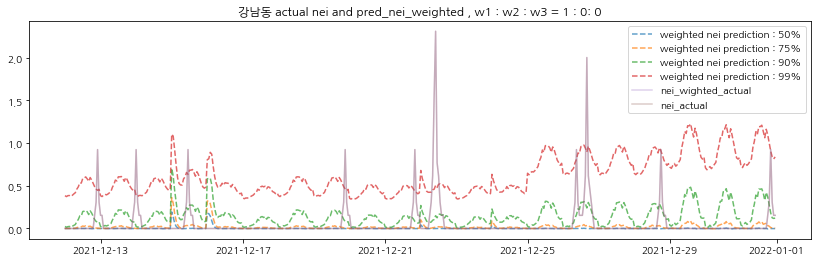

In [15]:
result('weighted_graph_data0.csv' , 'test/lightning_logs/version_0/checkpoints/epoch=199-step=1000.ckpt',1,0,0)

In [ ]:
result('weighted_graph_data1.csv' , 'test/lightning_logs/version_11/checkpoints/epoch=199-step=1000.ckpt',0,1,0)

In [ ]:
result('weighted_graph_data2.csv' , 'test/lightning_logs/version_2/checkpoints/epoch=199-step=1000.ckpt',0,0,1)

In [ ]:
result('weighted_graph_data3.csv' , 'test/lightning_logs/version_3/checkpoints/epoch=199-step=1000.ckpt',2,1,0.3)

In [ ]:
result('weighted_graph_data4.csv' , 'test/lightning_logs/version_4/checkpoints/epoch=199-step=1000.ckpt',2,0.5,0.2)

In [ ]:
result('weighted_graph_data5.csv' , 'test/lightning_logs/version_5/checkpoints/epoch=199-step=1000.ckpt',1,1,0)

In [ ]:
result('weighted_graph_data6.csv' , 'test/lightning_logs/version_6/checkpoints/epoch=199-step=1000.ckpt',5,1,0)

In [ ]:
result('weighted_graph_data7.csv' , 'test/lightning_logs/version_7/checkpoints/epoch=199-step=1000.ckpt',5,1,0.1)

In [ ]:
result('weighted_graph_data8.csv' , 'test/lightning_logs/version_8/checkpoints/epoch=199-step=1000.ckpt',1,5,0.1)

In [ ]:
result('weighted_graph_data9.csv' , 'test/lightning_logs/version_9/checkpoints/epoch=199-step=1000.ckpt',3,3,0.1)

In [ ]:
result('weighted_graph_data10.csv' , 'test/lightning_logs/version_10/checkpoints/epoch=199-step=1000.ckpt',10,2,0)

# result plot

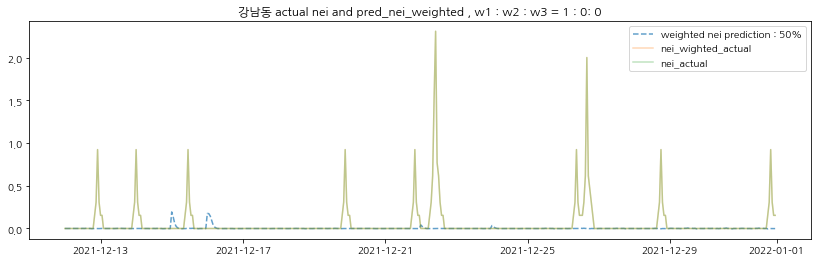

In [3]:
result('weighted_graph_data0.csv' , 'test/lightning_logs/version_0/checkpoints/epoch=199-step=1000.ckpt',1,0,0)

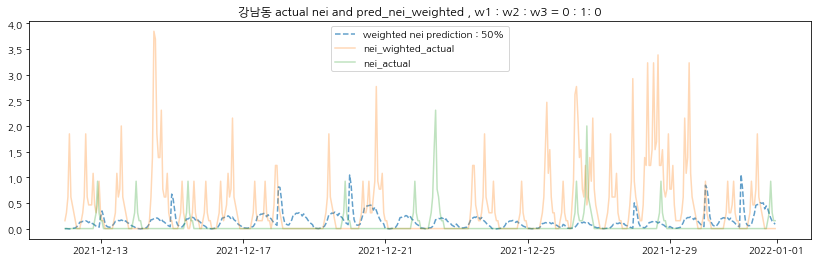

In [4]:
result('weighted_graph_data1.csv' , 'test/lightning_logs/version_11/checkpoints/epoch=199-step=1000.ckpt',0,1,0)

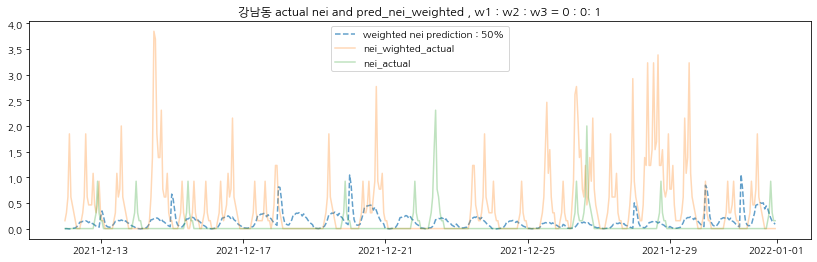

In [5]:
result('weighted_graph_data2.csv' , 'test/lightning_logs/version_2/checkpoints/epoch=199-step=1000.ckpt',0,0,1)

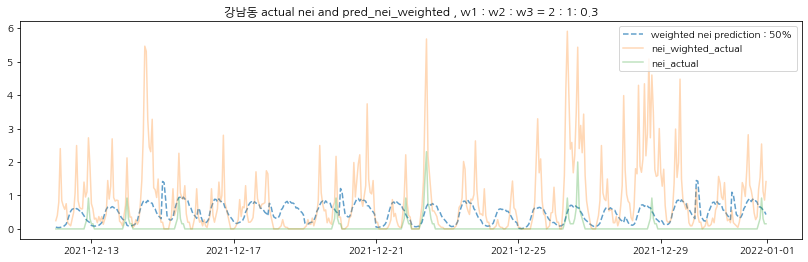

In [6]:
result('weighted_graph_data3.csv' , 'test/lightning_logs/version_3/checkpoints/epoch=199-step=1000.ckpt',2,1,0.3)

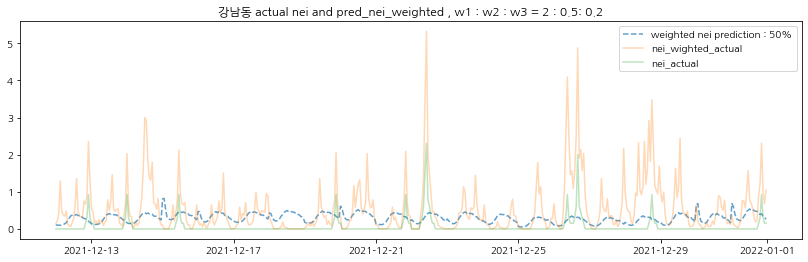

In [7]:
result('weighted_graph_data4.csv' , 'test/lightning_logs/version_4/checkpoints/epoch=199-step=1000.ckpt',2,0.5,0.2)

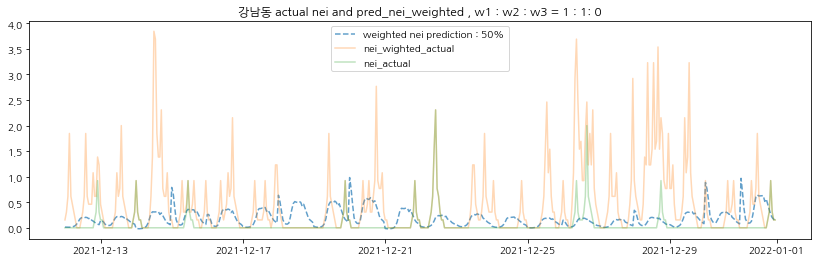

In [8]:
result('weighted_graph_data5.csv' , 'test/lightning_logs/version_5/checkpoints/epoch=199-step=1000.ckpt',1,1,0)

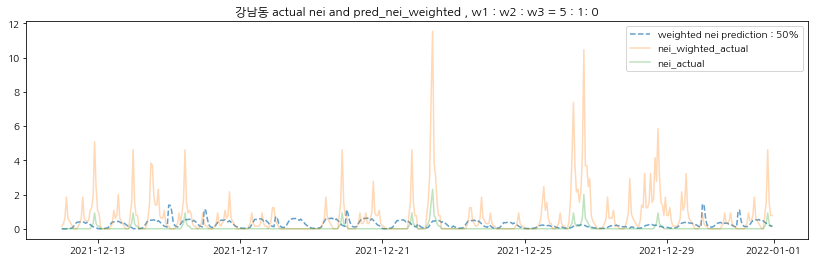

In [9]:
result('weighted_graph_data6.csv' , 'test/lightning_logs/version_6/checkpoints/epoch=199-step=1000.ckpt',5,1,0)

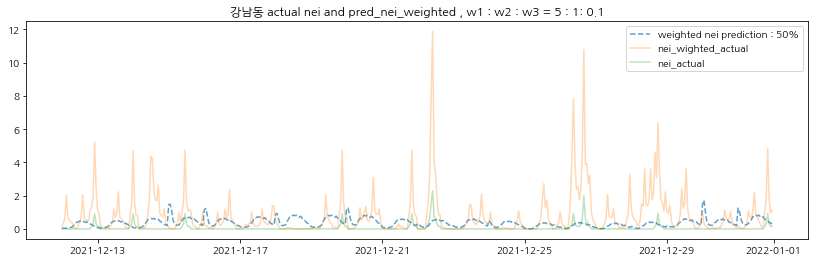

In [10]:
result('weighted_graph_data7.csv' , 'test/lightning_logs/version_7/checkpoints/epoch=199-step=1000.ckpt',5,1,0.1)

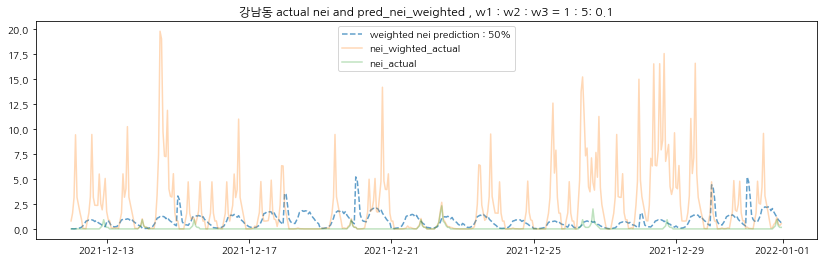

In [11]:
result('weighted_graph_data8.csv' , 'test/lightning_logs/version_8/checkpoints/epoch=199-step=1000.ckpt',1,5,0.1)

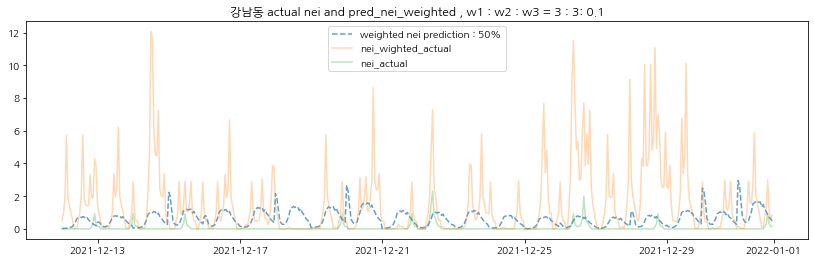

In [12]:
result('weighted_graph_data9.csv' , 'test/lightning_logs/version_9/checkpoints/epoch=199-step=1000.ckpt',3,3,0.1)

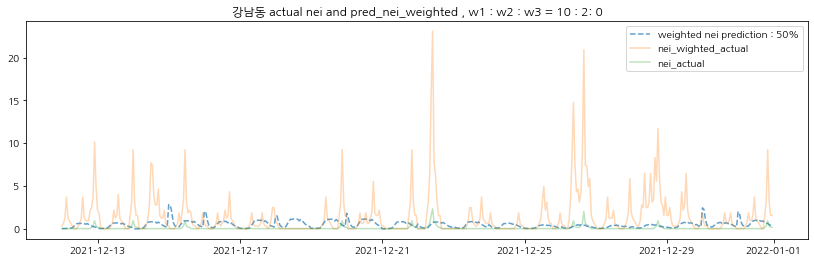

In [13]:
result('weighted_graph_data10.csv' , 'test/lightning_logs/version_10/checkpoints/epoch=199-step=1000.ckpt',10,2,0)